# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
import pathlib
import joblib
import numpy as np
import pandas as pd

# --- Scikit-learn Imports ---

# Model Selection and Utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing and Feature Engineering
from sklearn.preprocessing import (
    StandardScaler, 
    OneHotEncoder, 
    PowerTransformer, 
    PolynomialFeatures
)

# Models
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor
)

# Metrics
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score
)

In [7]:
# STEP 1: Imports
# ============================================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# Load data
# Use the correct CSV file path and format
df = pd.read_csv(r'C:\Users\amans\DSI WEEK 6\DSI Production\05_src\data\fires\forestfires.csv')


In [11]:
print(df.head())  # show first 5 rows
print(df.columns) # rint all column names




   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0
Index(['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH',
       'wind', 'rain', 'area'],
      dtype='object')


In [12]:
print(df.describe())  # Show numeric summary statistics
print(df.describe(include=["O"]))  # Show summary of object/categorical columns

                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain         area  
count  517.000000  517.000000  517.000000  517.000000   517.000000  
mean    18.889168   44.288201    4.017602    0.021663    12.847292  
std      5.806625   16.317469    1.791653    0.295959    63.655

In [13]:
print(df.shape)        # Show (row, column)
print(df.info())       #Show data types and missing values

(517, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None


#To summarize, 2 categorical and 9 numerical features (and one numerical target variable)
*Target (area) very skewed toward zero
*No missing values

In [25]:
df.isna().sum()

X           0
Y           0
month       0
day         0
FFMC        0
DMC         0
DC          0
ISI         0
temp        0
RH          0
wind        0
rain        0
area        0
log_area    0
dtype: int64

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X,517.0,4.669246,2.313778,1.0,3.0,4.00000,7.000000,9.00000
Y,517.0,4.299807,1.229900,2.0,4.0,4.00000,5.000000,9.00000
FFMC,517.0,90.644681,5.520111,18.7,90.2,91.60000,92.900000,96.20000
DMC,517.0,110.872340,64.046482,1.1,68.6,108.30000,142.400000,291.30000
DC,517.0,547.940039,248.066192,7.9,437.7,664.20000,713.900000,860.60000
ISI,517.0,9.021663,4.559477,0.0,6.5,8.40000,10.800000,56.10000
temp,517.0,18.889168,5.806625,2.2,15.5,19.30000,22.800000,33.30000
RH,517.0,44.288201,16.317469,15.0,33.0,42.00000,53.000000,100.00000
wind,517.0,4.017602,1.791653,0.4,2.7,4.00000,4.900000,9.40000
rain,517.0,0.021663,0.295959,0.0,0.0,0.00000,0.000000,6.40000


C:\Users\amans\AppData\Local\Temp\ipykernel_34228\4001384850.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


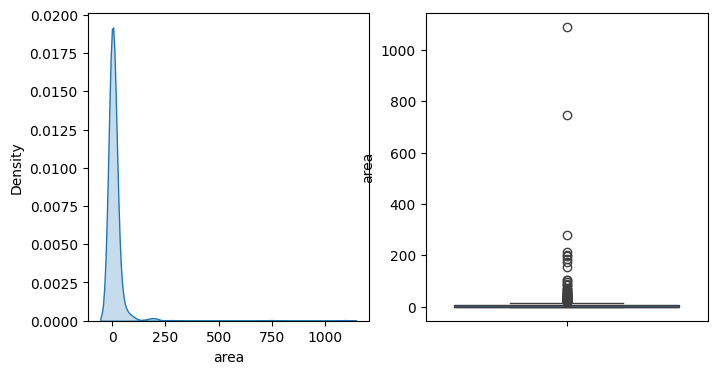

In [28]:
##Lets check skewness of target varible:
import matplotlib.pyplot as plt
import seaborn as sns  # you also need to import seaborn if you use sns.kdeplot or sns.boxplot
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax =plt.subplots(1,2,figsize=(8,4))
sns.kdeplot(df['area'],fill=True,ax=ax[0])
sns.boxplot(df['area'],ax=ax[1])
fig.show()

#as we can seee The target is heavily skewed toward small values, with larger ones being outliers. Because of this pronounced right skew, it's best to use a log transformation 



Skewness: 12.846933533934868
Skewness after log transform: 1.2178376559535011


C:\Users\amans\AppData\Local\Temp\ipykernel_34228\1895513975.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


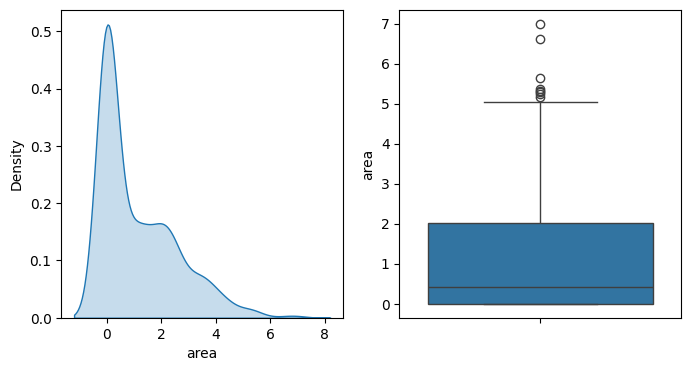

In [29]:
fig, ax =plt.subplots(1,2,figsize=(8,4))
sns.kdeplot(np.log(1+df['area']),fill=True,ax=ax[0])
sns.boxplot(np.log(1+df['area']),ax=ax[1])
fig.show()
area_log = np.log(1 + df['area'])
print('Skewness:',df['area'].skew())
print('Skewness after log transform:',area_log.skew())

# Get X and Y

Create the features data frame and target data.

In [57]:
# Load data
df = pd.read_csv(r'C:\Users\amans\DSI WEEK 6\DSI Production\05_src\data\fires\forestfires.csv')

# Log-transform target
df['log_area'] = np.log1p(df['area'])

# Create bins for stratified split
df['area_bin'] = pd.cut(df['log_area'], 5)

# Features and target
X = df.drop(columns=['area', 'log_area'])
y = df['log_area']

# Numeric and categorical columns
num_features = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
cat_features = ['month', 'day']

# Train/test split (stratified)
rs = 99
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=rs, stratify=df['area_bin']
)
X_train = X_train.drop(columns='area_bin', errors='ignore')
X_test = X_test.drop(columns='area_bin', errors='ignore')


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


In [58]:

# Preprocessor 1: scale + one-hot
preproc1 = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# Preprocessor 2: polynomial + scale + one-hot
preproc2 = ColumnTransformer([
    ('num', Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])



## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [59]:
pipeline_A = Pipeline([
    ('preprocessor', preproc1),
    ('regressor', Ridge())
])
pipeline_B = Pipeline([
    ('preprocessor', preproc2),
    ('regressor', Ridge())
])
pipeline_C = Pipeline([
    ('preprocessor', preproc1),
    ('regressor', RandomForestRegressor(random_state=rs))
])
pipeline_D = Pipeline([
    ('preprocessor', preproc2),
    ('regressor', RandomForestRegressor(random_state=rs))
])


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [60]:
param_grid_A = {'regressor__alpha': [0.1, 1, 10, 100]}
param_grid_B = {'regressor__alpha': [0.1, 1, 10, 100]}
param_grid_C = {
    'regressor__n_estimators': [100, 300],
    'regressor__max_depth': [None, 5, 10]
}
param_grid_D = {
    'regressor__n_estimators': [100, 300],
    'regressor__max_depth': [None, 5, 10]
}


# Evaluate

+ Which model has the best performance?

In [61]:
results = {}
for name, pipe, grid in [
    ('Pipeline_A', pipeline_A, param_grid_A),
    ('Pipeline_B', pipeline_B, param_grid_B),
    ('Pipeline_C', pipeline_C, param_grid_C),
    ('Pipeline_D', pipeline_D, param_grid_D)
]:
    print(f"\nRunning GridSearchCV for {name} ...")
    gs = GridSearchCV(pipe, grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_train, y_train)
    y_pred = np.expm1(gs.predict(X_test))
    y_true = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    print(f"Best Params: {gs.best_params_}")
    results[name] = {'model': gs.best_estimator_, 'rmse': rmse, 'mae': mae, 'r2': r2}



Running GridSearchCV for Pipeline_A ...
Pipeline_A: RMSE=64.468, MAE=13.873, R²=-0.032
Best Params: {'regressor__alpha': 100}

Running GridSearchCV for Pipeline_B ...
Pipeline_B: RMSE=64.424, MAE=13.841, R²=-0.031
Best Params: {'regressor__alpha': 100}

Running GridSearchCV for Pipeline_C ...
Pipeline_C: RMSE=64.378, MAE=13.730, R²=-0.030
Best Params: {'regressor__max_depth': 5, 'regressor__n_estimators': 300}

Running GridSearchCV for Pipeline_D ...
Pipeline_D: RMSE=64.376, MAE=13.753, R²=-0.030
Best Params: {'regressor__max_depth': 5, 'regressor__n_estimators': 300}


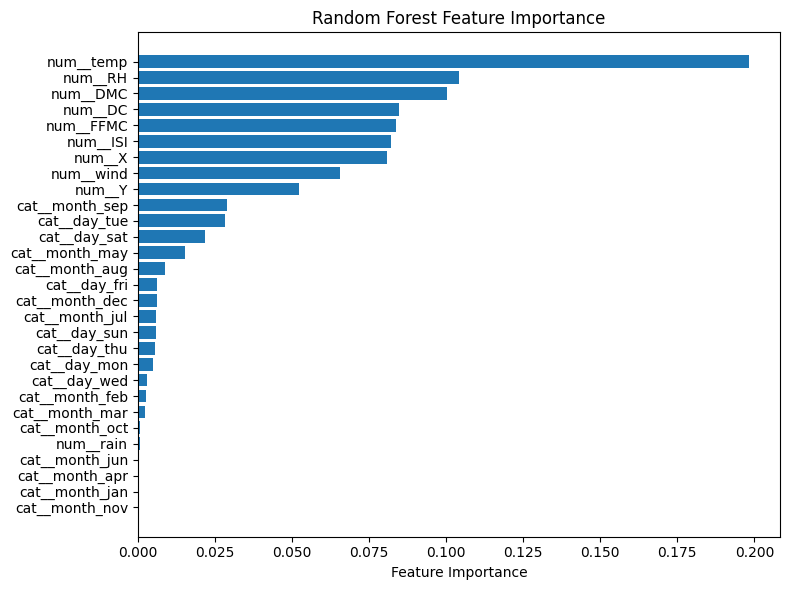

In [62]:
best_rf = results['Pipeline_C']['model']  # or Pipeline_D if it performed better
rf_reg = best_rf.named_steps['regressor']
rf_features = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = rf_reg.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(8,6))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), rf_features[indices])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()


# Export

+ Save the best performing model to a pickle file.

In [63]:
# Save the best model (choose the one with lowest RMSE)
best_model_name = min(results, key=lambda k: results[k]['rmse'])
best_model = results[best_model_name]['model']
joblib.dump(best_model, 'best_model.pkl')
print(f"Best model ({best_model_name}) saved as 'best_model.pkl'.")


Best model (Pipeline_D) saved as 'best_model.pkl'.


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

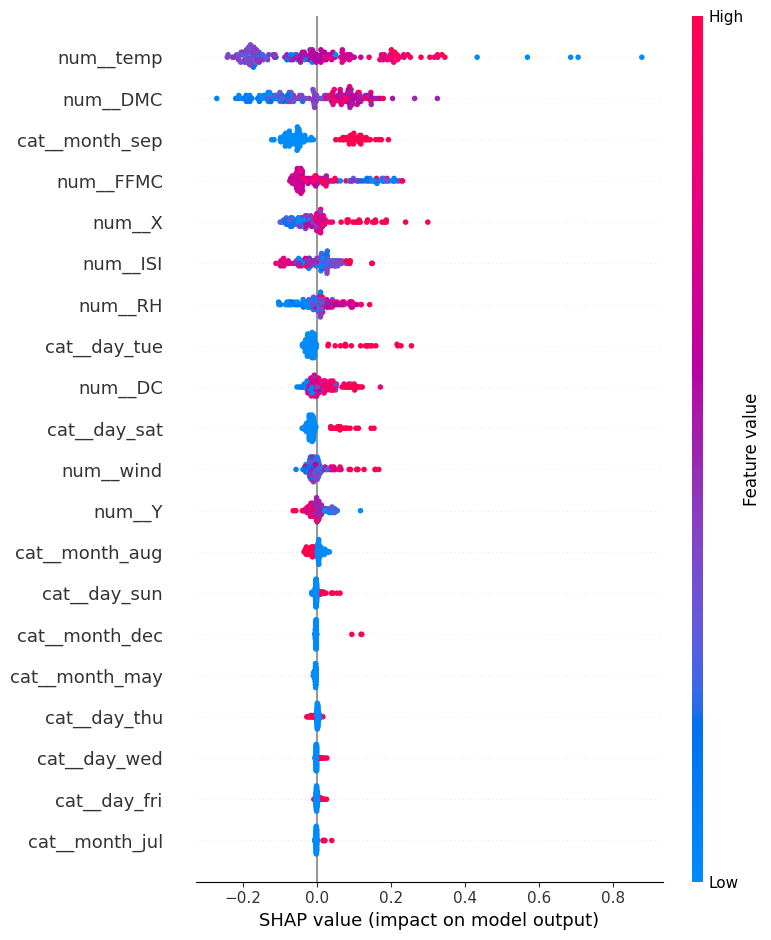

In [64]:
import shap
explainer = shap.TreeExplainer(rf_reg)
shap_values = explainer.shap_values(best_rf.named_steps['preprocessor'].transform(X_test))
shap.summary_plot(shap_values, best_rf.named_steps['preprocessor'].transform(X_test), feature_names=rf_features)


Most important features affecting burned area prediction are temperature, DMC, month (esp. September), and FFMC.

Least important are certain months (July, December) and days (Friday, Wednesday), so these could be dropped with no effect on accuracy.

The SHAP summary plot confirms model predictions rely mostly on weather and seasonal variables.



## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.